# Simple LangGraph RAG

This notebook builds a **Corrective RAG** pipeline using LangGraph with 5 nodes and conditional branching at two points.

**Graph flow:**
```
retrieve → grade_docs ──(relevant)──→ generate_answer → grade_answer ──(grounded)──→ END
               │                             ↑                 │
          (not relevant)                     │           (hallucination,
               ↓                             │            retries < 2)
          rewrite_query ────────────────────→┘
```

**Steps:**
1. Install dependencies
2. Set API keys
3. Ingest documents into a FAISS vector store
4. Define graph state
5. Initialize LLM
6. Define nodes
7. Build and compile the LangGraph
8. Visualize the graph
9. Ask questions

## 1. Install Dependencies

In [ ]:
%pip install -r requirements.txt -q


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Detect Environment & Set API Keys

- **Google Colab** — reads from Colab *Secrets* (the 🔑 panel in the left sidebar)
- **Local** — reads from `~/FDP-AGENENTIC-AI-RAG/.env`

In [2]:
import os
from dotenv import load_dotenv

load_dotenv(os.path.expanduser("~/FDP-AGENENTIC-AI-RAG/.env"))

HF_TOKEN = os.getenv("HF_TOKEN") 
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

## 3. Ingest Documents into FAISS Vector Store

Defines knowledge inline, splits it into chunks, embeds them using HuggingFace, and saves the vector store locally.

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

knowledge = [
   "The Department of Intelligent Systems Engineering (DISE) is a small, focused department that works on applied AI and intelligent systems.",
    "It currently has around 40 students, with a healthy mix of undergraduate and postgraduate learners.",
    "The department is run by a team of 14 professors, including experienced faculty members and a few industry practitioners.",
    "Students can choose from about 5 courses, ranging from core subjects to electives and hands-on project work.",
    "Overall, DISE aims to prepare students for real-world engineering roles through practical learning and industry exposure.",
]

documents = [Document(page_content=text) for text in knowledge]

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
docs = splitter.split_documents(documents)

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L12-v2"
)

db = FAISS.from_documents(docs, embeddings)
db.save_local("vectorstore")

print(f"Vector DB created successfully ({len(docs)} chunks)")

/tmp/ipykernel_62323/3940480202.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Vector DB created successfully (5 chunks)


## 4. Define Graph State

In [4]:
from typing import TypedDict


class GraphState(TypedDict):
    question: str        # current question (may be rewritten)
    retrieved_docs: str  # concatenated chunk text
    doc_grade: str       # "relevant" | "not_relevant"
    answer: str          # generated answer
    answer_grade: str    # "grounded" | "hallucination"
    retries: int         # generation attempts so far

## 5. Initialize LLM (Model-Agnostic)

Uses LangChain's `init_chat_model` — swap providers by setting `MODEL_NAME` before running this cell:

| Provider | `MODEL_NAME` value |
|---|---|
| HuggingFace *(default)* | `huggingface:TinyLlama/TinyLlama-1.1B-Chat-v1.0` |
| Google Gemini | `google_genai:gemini-2.5-flash` |
| OpenAI | `openai:gpt-4o` |
| Anthropic | `anthropic:claude-sonnet-4-6` |
| Ollama (local) | `ollama:llama3` |

In [10]:
from langchain.chat_models import init_chat_model

MODEL_NAME = "huggingface:TinyLlama/TinyLlama-1.1B-Chat-v1.0"
#MODEL_NAME = "google_genai:gemini-2.5-flash"

llm = init_chat_model(
    MODEL_NAME,
   api_key=HF_TOKEN,
    #api_key=GEMINI_API_KEY,
    temperature=0.1,
)

print(f"LLM ready (model: {MODEL_NAME})")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

LLM ready (model: huggingface:TinyLlama/TinyLlama-1.1B-Chat-v1.0)


## 6. Define Graph Nodes

Five nodes with conditional branching at two points:

| Node | Role |
|---|---|
| **retrieve** | Fetch top-k chunks from the vector store |
| **grade_docs** | LLM decides if retrieved docs are relevant to the question |
| **rewrite_query** | LLM rewrites the question when docs are not relevant |
| **generate_answer** | LLM answers using the retrieved context |
| **grade_answer** | LLM checks whether the answer is grounded in the docs |

Routing:
- After `grade_docs` → `generate_answer` if relevant, else `rewrite_query → retrieve`
- After `grade_answer` → `END` if grounded, else retry `generate_answer` (max 2 attempts)

In [6]:
db = FAISS.load_local(
    "vectorstore",
    embeddings,
    allow_dangerous_deserialization=True,
)


# ── Node 1: Retrieve ────────────────────────────────────────────────────────

def retrieve(state: GraphState) -> dict:
    docs = db.similarity_search(state["question"], k=3)
    retrieved_text = "\n".join([doc.page_content for doc in docs])
    print("\n[retrieve] fetched", len(docs), "chunks")
    return {"retrieved_docs": retrieved_text}


# ── Node 2: Grade Docs ──────────────────────────────────────────────────────

def grade_docs(state: GraphState) -> dict:
    prompt = f"""Are the retrieved documents relevant to the question?
Reply with exactly one word: relevant or not_relevant.

Question: {state["question"]}
Documents: {state["retrieved_docs"]}"""
    result = llm.invoke(prompt).content.strip().lower()
    grade = "relevant" if "relevant" in result else "not_relevant"
    print(f"\n[grade_docs] {grade}")
    return {"doc_grade": grade}


def route_after_grade_docs(state: GraphState) -> str:
    return "generate_answer" if state["doc_grade"] == "relevant" else "rewrite_query"


# ── Node 3: Rewrite Query ───────────────────────────────────────────────────

def rewrite_query(state: GraphState) -> dict:
    prompt = f"""Rewrite the question to improve retrieval. Return only the rewritten question.

Original question: {state["question"]}"""
    rewritten = llm.invoke(prompt).content.strip()
    print(f"\n[rewrite_query] {rewritten}")
    return {"question": rewritten}


# ── Node 4: Generate Answer ─────────────────────────────────────────────────

def generate_answer(state: GraphState) -> dict:
    prompt = f"""Answer the question using only the context below.

Context:
{state["retrieved_docs"]}

Question:
{state["question"]}"""
    response = llm.invoke(prompt)
    print("\n[generate_answer] done")
    return {
        "answer": response.content,
        "retries": state.get("retries", 0) + 1,
    }


# ── Node 5: Grade Answer ────────────────────────────────────────────────────

def grade_answer(state: GraphState) -> dict:
    prompt = f"""Is the answer grounded in the provided context, or does it contain hallucinations?
Reply with exactly one word: grounded or hallucination.

Context: {state["retrieved_docs"]}
Answer: {state["answer"]}"""
    result = llm.invoke(prompt).content.strip().lower()
    grade = "grounded" if "grounded" in result else "hallucination"
    print(f"\n[grade_answer] {grade}")
    return {"answer_grade": grade}


def route_after_grade_answer(state: GraphState) -> str:
    if state["answer_grade"] == "grounded" or state.get("retries", 0) >= 2:
        return "end"
    print("\n[grade_answer] hallucination detected — retrying generation")
    return "retry"

## 7. Build and Compile the LangGraph

In [7]:
from langgraph.graph import StateGraph, END

graph = StateGraph(GraphState)

# Register nodes
graph.add_node("retrieve", retrieve)
graph.add_node("grade_docs", grade_docs)
graph.add_node("rewrite_query", rewrite_query)
graph.add_node("generate_answer", generate_answer)
graph.add_node("grade_answer", grade_answer)

# Entry point
graph.set_entry_point("retrieve")

# Fixed edges
graph.add_edge("retrieve", "grade_docs")
graph.add_edge("rewrite_query", "retrieve")
graph.add_edge("generate_answer", "grade_answer")

# Conditional edge 1: after grading docs
graph.add_conditional_edges(
    "grade_docs",
    route_after_grade_docs,
    {"generate_answer": "generate_answer", "rewrite_query": "rewrite_query"},
)

# Conditional edge 2: after grading answer
graph.add_conditional_edges(
    "grade_answer",
    route_after_grade_answer,
    {"end": END, "retry": "generate_answer"},
)

app = graph.compile()

print("LangGraph compiled successfully")

LangGraph compiled successfully


## 8. Visualize the Graph

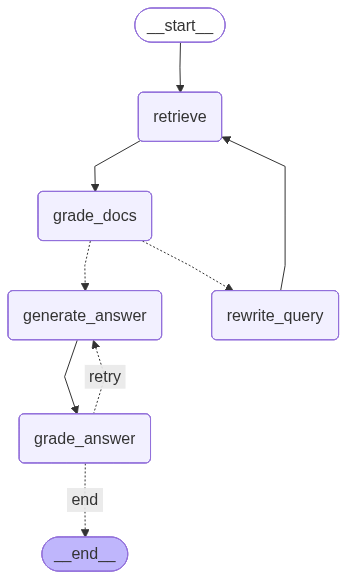

In [8]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 9. Ask Questions

Edit `question` below and re-run this cell to query the graph.

In [11]:
def ask(question: str):
    result = app.invoke({
        "question": question,
        "retrieved_docs": "",
        "doc_grade": "",
        "answer": "",
        "answer_grade": "",
        "retries": 0,
    })
    print("\nAnswer:", result["answer"])


ask("What is DISE?")


[retrieve] fetched 3 chunks


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer LlamaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



[grade_docs] relevant

[generate_answer] done

[grade_answer] grounded

Answer: <|user|>
Answer the question using only the context below.

Context:
The Department of Intelligent Systems Engineering (DISE) is a small, focused department that works on applied AI and intelligent systems.
Overall, DISE aims to prepare students for real-world engineering roles through practical learning and industry exposure.
It currently has around 40 students, with a healthy mix of undergraduate and postgraduate learners.

Question:
What is DISE?</s>
<|assistant|>
DISE (Department of Intelligent Systems Engineering) is a small, focused department that works on applied AI and intelligent systems. It aims to prepare students for real-world engineering roles through practical learning and industry exposure. It currently has around 40 students, with a mix of undergraduate and postgraduate learners.


In [12]:
ask("Purpose of DISE?")


[retrieve] fetched 3 chunks

[grade_docs] relevant

[generate_answer] done

[grade_answer] grounded

Answer: <|user|>
Answer the question using only the context below.

Context:
The Department of Intelligent Systems Engineering (DISE) is a small, focused department that works on applied AI and intelligent systems.
Overall, DISE aims to prepare students for real-world engineering roles through practical learning and industry exposure.
It currently has around 40 students, with a healthy mix of undergraduate and postgraduate learners.

Question:
Purpose of DISE?</s>
<|assistant|>
The purpose of the Department of Intelligent Systems Engineering (DISE) at the University of Oxford is to prepare students for real-world engineering roles through practical learning and industry exposure. The department currently has around 40 students, with a mix of undergraduate and postgraduate learners. Its focus is on applied AI and intelligent systems, and it aims to prepare students for engineering roles